# Read and plot measurement data

## Setup and helper functions

In [89]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

plt.rcParams.update({
    "figure.figsize": (10, 7),
    "axes.grid": True,
})

COLUMNS = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi",
]


def find_project_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "data" / "Daten final").exists():
            return path
    raise FileNotFoundError("Could not find the project root with data/Daten final.")


def load_measurements(data_dir=None, selected_file=None):
    project_root = find_project_root()
    data_dir = Path(data_dir) if data_dir is not None else project_root / "data" / "Daten final"

    if selected_file is None:
        file_paths = sorted(data_dir.glob("*.TXT")) + sorted(data_dir.glob("*.txt"))
    else:
        file_path = data_dir / selected_file
        if not file_path.exists():
            raise FileNotFoundError(f"File not found: {file_path}")
        file_paths = [file_path]

    if not file_paths:
        raise FileNotFoundError(f"No .TXT files found in: {data_dir}")

    frames = []
    for path in file_paths:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            skiprows=4,
            names=COLUMNS,
            encoding="latin1",
            engine="python",
        )

        parts = path.stem.split("_")
        material = parts[0] if len(parts) >= 1 else path.stem
        temperature = parts[1] if len(parts) >= 2 else None
        mode = parts[2] if len(parts) >= 3 else None

        first_freq = df["Freq_Hz"].iloc[0]
        df["Spectrum_ID"] = (df["Freq_Hz"] == first_freq).cumsum() - 1
        df["Spectrum_Number"] = df["Spectrum_ID"] + 1
        df["Point_Number"] = range(1, len(df) + 1)
        df["Material"] = material
        df["Temperature"] = temperature
        df["Mode"] = mode
        df["Source_File"] = path.name

        frames.append(df)

    return pd.concat(frames, ignore_index=True)


def filter_dataset(df, material, temperature, mode):
    return df[
        (df["Material"] == material)
        & (df["Temperature"] == temperature)
        & (df["Mode"] == mode)
    ].copy()


def print_available_datasets(df):
    available = (
        df[["Material", "Temperature", "Mode"]]
        .drop_duplicates()
        .sort_values(["Material", "Temperature", "Mode"])
    )
    print(available.to_string(index=False))

## Load raw data

In [90]:
df_all = load_measurements()

print(f"Rows: {len(df_all):,}")
print(f"Files: {df_all['Source_File'].nunique()}")
print(df_all.head())

Rows: 115,816
Files: 14
   Freq_Hz  Time_s  Eps_real  Eps_imag  Temp_K  MTime_s  Phi_deg  Z_real_Ohm  \
0   100.00     0.0    1.8326  0.038560  323.11    11.10      NaN         NaN   
1   150.00     0.0    1.8229  0.038089  323.12    13.52      NaN         NaN   
2   225.00     0.0    1.8149  0.040726  323.12    18.82      NaN         NaN   
3   337.50     0.0    1.8052  0.042731  323.12    21.63      NaN         NaN   
4   506.25     0.0    1.7949  0.045478  323.13    24.07      NaN         NaN   

   Z_imag_Ohm  TanPhi  Spectrum_ID  Spectrum_Number  Point_Number  Material  \
0         NaN     NaN            0                1             1  PEI2mgmL   
1         NaN     NaN            0                1             2  PEI2mgmL   
2         NaN     NaN            0                1             3  PEI2mgmL   
3         NaN     NaN            0                1             4  PEI2mgmL   
4         NaN     NaN            0                1             5  PEI2mgmL   

  Temperature Mode  

In [91]:
series_counts = (
    df_all.groupby(["Material", "Temperature", "Mode"], dropna=False)
    .agg(
        Point_Count=("Point_Number", "count"),
        Spectrum_Count=("Spectrum_Number", "nunique"),
        First_MTime_s=("MTime_s", "min"),
        Last_MTime_s=("MTime_s", "max"),
    )
    .reset_index()
    .sort_values(["Material", "Temperature", "Mode"])
)

print(series_counts.to_string(index=False))

Material Temperature Mode  Point_Count  Spectrum_Count  First_MTime_s  Last_MTime_s
PEI2mgmL        50°C  Abs         8122             170          11.10       13060.0
PEI2mgmL        50°C  Des        11846             247          11.39       19922.0
PEI2mgmL        90°C  Abs         7698             161           8.39       10605.0
PEI2mgmL        90°C  Des        11660             243           8.67       16351.0
PEI5mgmL        50°C  Abs         5808             121           7.78        9445.3
PEI5mgmL        50°C  Des         3350              70           7.78        5376.5
PEI5mgmL        60°C  Abs         6622             138           7.53       10776.0
PEI5mgmL        60°C  Des         9980             208           7.75       16530.0
PEI5mgmL        70°C  Abs         5714             120           7.76        9300.5
PEI5mgmL        70°C  Des        13308             278           7.69       22114.0
PEI5mgmL        80°C  Abs         9096             190           7.83       

## Inspect raw data before setting the atmosphere switch

Point ranges of the plotted spectra:
 Spectrum_Number  Point_Start  Point_End  Time_Start_s  Time_End_s
               5           97        120         321.0       394.0
               6          121        144         401.1       473.1
               7          145        168         479.6       550.0


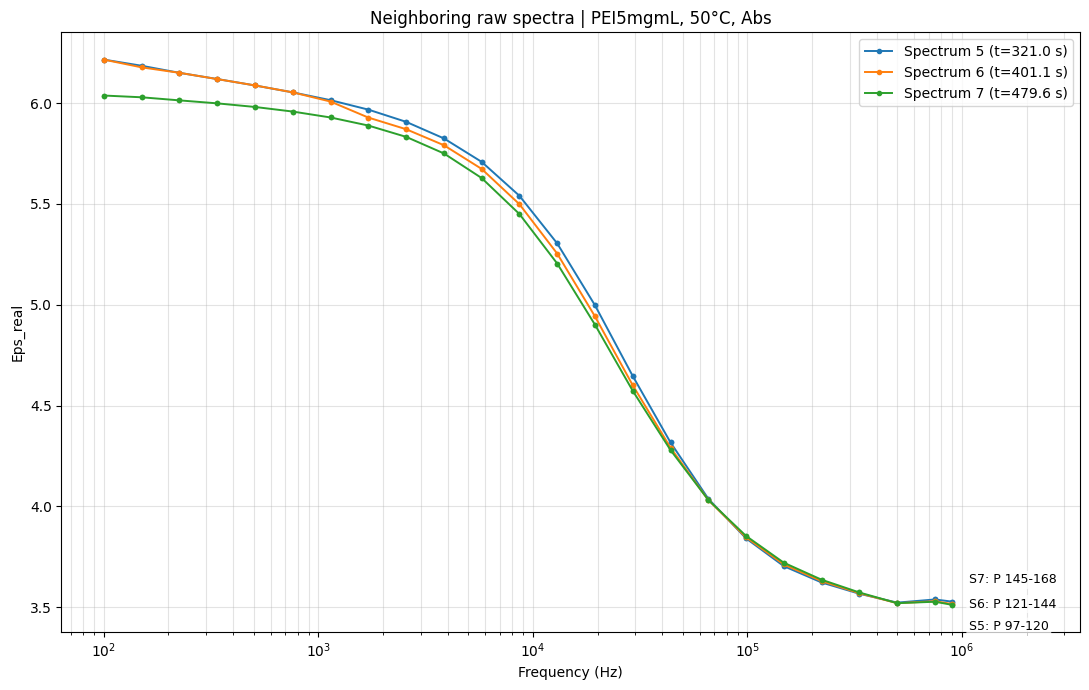

In [92]:
material = "PEI5mgmL"
temperature = "50°C"
mode = "Abs"
y_col = "Eps_real"
spectrum_numbers = [5, 6, 7]

# Use this plot to compare neighboring spectra before assigning a switch point.
df_sel = filter_dataset(df_all, material, temperature, mode)

if df_sel.empty:
    print_available_datasets(df_all)
    raise ValueError(f"No data found for {material}, {temperature}, {mode}.")

if y_col not in df_sel.columns:
    raise ValueError(f"Column not found: {y_col}")

spectrum_ids = [number - 1 for number in spectrum_numbers]
available_ids = sorted(df_sel["Spectrum_ID"].unique())
missing_numbers = [
    number
    for number, spec_id in zip(spectrum_numbers, spectrum_ids)
    if spec_id not in available_ids
]

if missing_numbers:
    available_numbers = [spec_id + 1 for spec_id in available_ids]
    raise ValueError(f"Missing spectra: {missing_numbers}. Available spectra: {available_numbers}")

fig, ax = plt.subplots(figsize=(11, 7))
spectrum_summary = []
label_y_offsets = [-18, 0, 18, 36, -36]

for plot_index, (number, spec_id) in enumerate(zip(spectrum_numbers, spectrum_ids)):
    spec = df_sel[df_sel["Spectrum_ID"] == spec_id].sort_values("Freq_Hz")
    time_start = spec["MTime_s"].iloc[0]
    time_end = spec["MTime_s"].iloc[-1]
    point_start = int(spec["Point_Number"].min())
    point_end = int(spec["Point_Number"].max())

    ax.plot(
        spec["Freq_Hz"],
        spec[y_col],
        marker="o",
        markersize=3,
        linewidth=1.4,
        label=f"Spectrum {number} (t={time_start:.1f} s)",
    )

    label_point = spec.iloc[-1]
    ax.annotate(
        f"S{number}: P {point_start}-{point_end}",
        (label_point["Freq_Hz"], label_point[y_col]),
        textcoords="offset points",
        xytext=(12, label_y_offsets[plot_index % len(label_y_offsets)]),
        ha="left",
        va="center",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.75, "edgecolor": "none"},
    )

    spectrum_summary.append({
        "Spectrum_Number": number,
        "Point_Start": point_start,
        "Point_End": point_end,
        "Time_Start_s": round(float(time_start), 1),
        "Time_End_s": round(float(time_end), 1),
    })

ax.set_xscale("log")
xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax * 2.5)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(y_col)
ax.set_title(f"Neighboring raw spectra | {material}, {temperature}, {mode}")
ax.grid(True, which="both", alpha=0.35)
ax.legend()
plt.tight_layout()

print("Point ranges of the plotted spectra:")
print(pd.DataFrame(spectrum_summary).to_string(index=False))
plt.show()

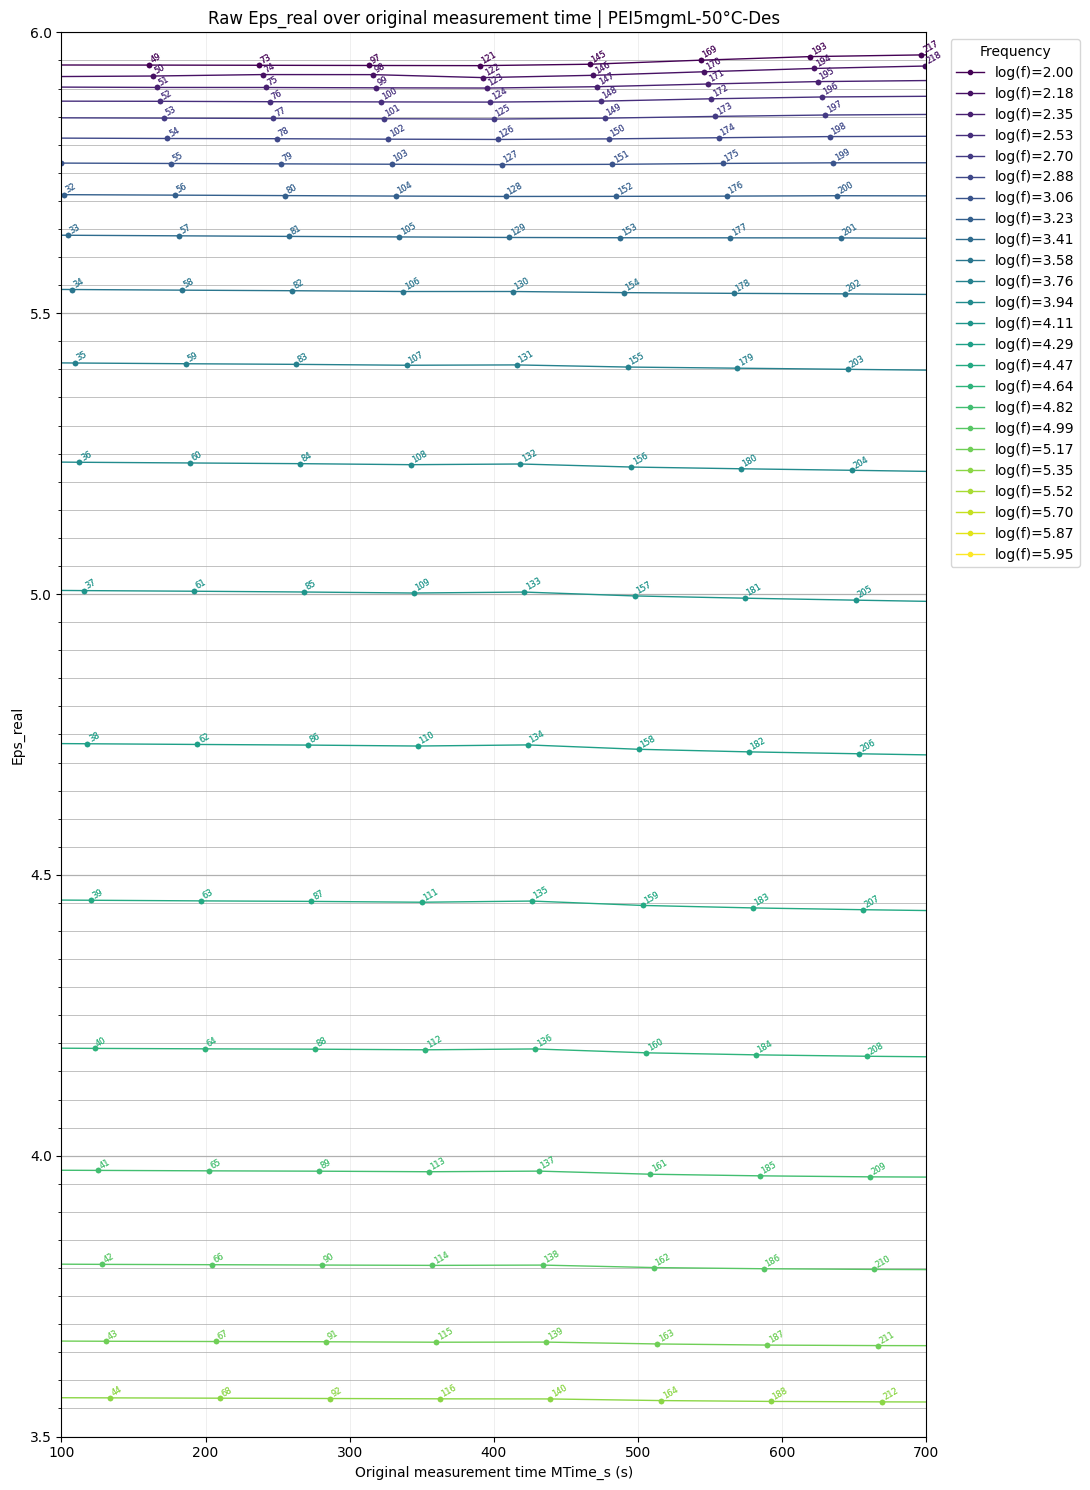

In [93]:
material = "PEI5mgmL"
temperature = "50°C"
mode = "Des"
y_col = "Eps_real"
x_col = "MTime_s"

# xlim filters the underlying data. Use None to keep every measured point.
xlim = None

# visible_xlim and visible_ylim only control the displayed view.
visible_xlim = (100, 700)
visible_ylim = (3.5, 6)

# Use None to plot every frequency. Use e.g. 14 for a cleaner logarithmic subset.
max_frequencies_to_plot = None

annotate_point_numbers = True
point_label_col = "Point_Number"
point_label_fontsize = 6
point_label_every_n = 1

df_sel = filter_dataset(df_all, material, temperature, mode)

if df_sel.empty:
    print_available_datasets(df_all)
    raise ValueError(f"No data found for {material}, {temperature}, {mode}.")

if x_col not in df_sel.columns:
    raise ValueError(f"Time column not found: {x_col}")

if annotate_point_numbers and point_label_col not in df_sel.columns:
    raise ValueError(f"Point-label column not found: {point_label_col}")

if xlim is not None:
    df_sel = df_sel[df_sel[x_col].between(xlim[0], xlim[1])]

if df_sel.empty:
    raise ValueError("No data found in the selected time range.")

frequencies = np.sort(df_sel["Freq_Hz"].dropna().unique())

if max_frequencies_to_plot is not None and len(frequencies) > max_frequencies_to_plot:
    target_freqs = np.geomspace(frequencies.min(), frequencies.max(), max_frequencies_to_plot)
    frequencies = np.array([
        frequencies[np.abs(frequencies - target_freq).argmin()]
        for target_freq in target_freqs
    ])
    frequencies = np.unique(frequencies)

colors = plt.cm.viridis(np.linspace(0, 1, len(frequencies)))
fig, ax = plt.subplots(figsize=(11, 15))

for freq, color in zip(frequencies, colors):
    freq_df = df_sel[df_sel["Freq_Hz"] == freq].sort_values(x_col)
    label = f"log(f)={np.log10(freq):.2f}"

    ax.plot(
        freq_df[x_col],
        freq_df[y_col],
        marker="o",
        markersize=3,
        linewidth=1,
        color=color,
        label=label,
    )

    if annotate_point_numbers:
        label_df = freq_df.iloc[::point_label_every_n]
        if visible_xlim is not None:
            label_df = label_df[label_df[x_col].between(visible_xlim[0], visible_xlim[1])]
        if visible_ylim is not None:
            label_df = label_df[label_df[y_col].between(visible_ylim[0], visible_ylim[1])]

        for _, row in label_df.iterrows():
            ax.text(
                row[x_col],
                row[y_col],
                str(int(row[point_label_col])),
                color=color,
                fontsize=point_label_fontsize,
                ha="left",
                va="bottom",
                rotation=30,
                alpha=0.85,
            )

ax.set_xlabel(f"Original measurement time {x_col} (s)")
ax.set_ylabel(y_col)

if visible_xlim is not None:
    ax.set_xlim(*visible_xlim)
if visible_ylim is not None:
    ax.set_ylim(*visible_ylim)

ax.set_title(f"Raw {y_col} over original measurement time | {material}-{temperature}-{mode}")
ax.yaxis.set_minor_locator(AutoMinorLocator(10))
ax.grid(True, axis="y", which="major", alpha=1.0, linewidth=0.9)
ax.grid(True, axis="y", which="minor", alpha=1.0, linewidth=0.55)
ax.grid(True, axis="x", which="major", alpha=0.2, linewidth=0.7)
ax.legend(title="Frequency", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Set atmosphere switch points and calculate relative time

In [94]:
# Enter the manually read point number directly before the atmosphere switch.
manual_switch_points = {
    ("PEI2mgmL", "50°C", "Abs"): 132,
    ("PEI2mgmL", "50°C", "Des"): 145,
    ("PEI2mgmL", "90°C", "Abs"): 151,
    ("PEI2mgmL", "90°C", "Des"): 152,
    ("PEI5mgmL", "50°C", "Abs"): 127,
    ("PEI5mgmL", "50°C", "Des"): 145,
    ("PEI5mgmL", "60°C", "Abs"): 127,
    ("PEI5mgmL", "60°C", "Des"): 145,
    ("PEI5mgmL", "70°C", "Abs"): 127,
    ("PEI5mgmL", "70°C", "Des"): 145,
    ("PEI5mgmL", "80°C", "Abs"): 128,
    ("PEI5mgmL", "80°C", "Des"): 128,
    ("PEI5mgmL", "90°C", "Abs"): 128,
    ("PEI5mgmL", "90°C", "Des"): 128,
}

series_overview = (
    df_all.groupby(["Material", "Temperature", "Mode"], dropna=False)
    .agg(
        First_Point=("Point_Number", "min"),
        Last_Point=("Point_Number", "max"),
        Spectrum_Count=("Spectrum_Number", "nunique"),
    )
    .reset_index()
    .sort_values(["Material", "Temperature", "Mode"])
)

atmosphere_switch_points = series_overview.copy()
atmosphere_switch_points["Switch_Point_Number"] = atmosphere_switch_points.apply(
    lambda row: manual_switch_points.get((row["Material"], row["Temperature"], row["Mode"])),
    axis=1,
)

invalid_switch_points = atmosphere_switch_points[
    atmosphere_switch_points["Switch_Point_Number"].notna()
    & ~atmosphere_switch_points["Switch_Point_Number"].between(
        atmosphere_switch_points["First_Point"],
        atmosphere_switch_points["Last_Point"],
    )
]

if not invalid_switch_points.empty:
    raise ValueError(
        "At least one Switch_Point_Number is outside the available point range:\n"
        + invalid_switch_points.to_string(index=False)
    )

switch_time_rows = []
for _, row in atmosphere_switch_points.dropna(subset=["Switch_Point_Number"]).iterrows():
    switch_point_number = int(row["Switch_Point_Number"])
    switch_row = df_all[
        (df_all["Material"] == row["Material"])
        & (df_all["Temperature"] == row["Temperature"])
        & (df_all["Mode"] == row["Mode"])
        & (df_all["Point_Number"] == switch_point_number)
    ]
    next_row = df_all[
        (df_all["Material"] == row["Material"])
        & (df_all["Temperature"] == row["Temperature"])
        & (df_all["Mode"] == row["Mode"])
        & (df_all["Point_Number"] == switch_point_number + 1)
    ]

    if switch_row.empty or next_row.empty:
        raise ValueError(
            "No measurement-point pair found for the entered switch point: "
            f"Material={row['Material']}, Temperature={row['Temperature']}, "
            f"Mode={row['Mode']}, Point_Number={switch_point_number}"
        )

    switch_time_rows.append({
        "Material": row["Material"],
        "Temperature": row["Temperature"],
        "Mode": row["Mode"],
        "Switch_Time_s": float((switch_row["MTime_s"].iloc[0] + next_row["MTime_s"].iloc[0]) / 2),
    })

switch_times = pd.DataFrame(switch_time_rows)

if switch_times.empty:
    raise ValueError("No Switch_Point_Number values were entered.")

df_all = df_all.drop(columns=["Switch_Time_s", "Time_Relative_s"], errors="ignore")
df_all = df_all.merge(switch_times, on=["Material", "Temperature", "Mode"], how="left")

missing_switch_times = df_all[df_all["Switch_Time_s"].isna()][
    ["Material", "Temperature", "Mode"]
].drop_duplicates()

if not missing_switch_times.empty:
    raise ValueError(
        "At least one dataset is missing a Switch_Point_Number:\n"
        + missing_switch_times.to_string(index=False)
    )

df_all["Time_Relative_s"] = df_all["MTime_s"] - df_all["Switch_Time_s"]

atmosphere_switch_points = atmosphere_switch_points.merge(
    switch_times,
    on=["Material", "Temperature", "Mode"],
    how="left",
)

print(atmosphere_switch_points.to_string(index=False))

Material Temperature Mode  First_Point  Last_Point  Spectrum_Count  Switch_Point_Number  Switch_Time_s
PEI2mgmL        50°C  Abs            1        4061             170                  132        456.195
PEI2mgmL        50°C  Des            1        5923             247                  145        469.395
PEI2mgmL        90°C  Abs            1        3849             161                  151        429.400
PEI2mgmL        90°C  Des            1        5830             243                  152        423.750
PEI5mgmL        50°C  Abs            1        2904             121                  127        420.430
PEI5mgmL        50°C  Des            1        1675              70                  145        467.765
PEI5mgmL        60°C  Abs            1        3311             138                  127        425.780
PEI5mgmL        60°C  Des            1        4990             208                  145        478.120
PEI5mgmL        70°C  Abs            1        2857             120       

## Frequency spectra after setting relative time

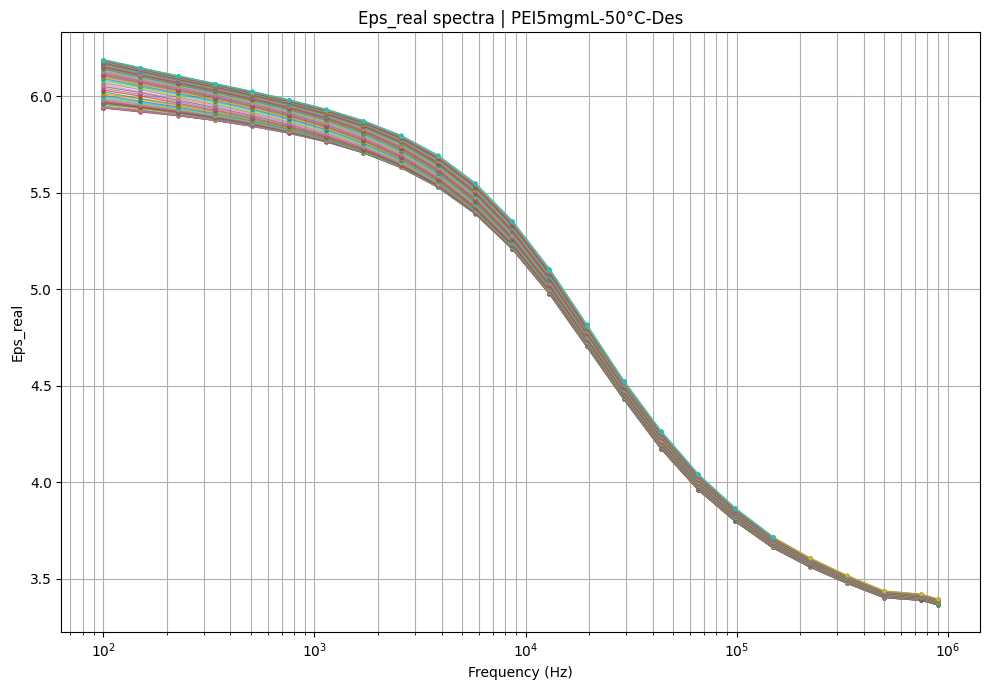

In [95]:
material = "PEI5mgmL"
temperature = "50°C"
mode = "Des"
y_col = "Eps_real"

df_sel = filter_dataset(df_all, material, temperature, mode)

if df_sel.empty:
    print_available_datasets(df_all)
    raise ValueError(f"No data found for {material}, {temperature}, {mode}.")

fig, ax = plt.subplots(figsize=(10, 7))
group_cols = ["Source_File", "Material", "Temperature", "Mode", "Spectrum_ID"]

for _, spec in df_sel.groupby(group_cols, dropna=False):
    spec = spec.sort_values("Freq_Hz")
    ax.plot(
        spec["Freq_Hz"],
        spec[y_col],
        marker="o",
        markersize=2,
        linewidth=1,
        alpha=0.7,
    )

ax.set_xscale("log")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel(y_col)
ax.set_title(f"{y_col} spectra | {material}-{temperature}-{mode}")
ax.grid(True, which="both")
plt.tight_layout()
plt.show()

## Time series at one frequency

In [96]:
def build_nearest_frequency_time_series(df, material, mode, temperature, target_frequency, value_col):
    df_sel = filter_dataset(df, material, temperature, mode)

    if df_sel.empty:
        return pd.DataFrame(columns=["Time_Relative_s", value_col])

    rows = []
    for _, spec in df_sel.groupby("Spectrum_ID", dropna=False):
        row = spec.loc[(spec["Freq_Hz"] - target_frequency).abs().idxmin()]
        rows.append({
            "Time_Relative_s": spec["Time_Relative_s"].iloc[0],
            value_col: row[value_col],
        })

    return pd.DataFrame(rows).sort_values("Time_Relative_s")


def plot_temperature_time_series(df, material, mode, target_frequency, value_col):
    fig, ax = plt.subplots(figsize=(9, 6))
    temperatures = sorted(df["Temperature"].dropna().unique())

    for temperature in temperatures:
        time_series = build_nearest_frequency_time_series(
            df,
            material=material,
            mode=mode,
            temperature=temperature,
            target_frequency=target_frequency,
            value_col=value_col,
        )

        if time_series.empty:
            continue

        ax.plot(
            time_series["Time_Relative_s"],
            time_series[value_col],
            marker="o",
            label=temperature,
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Time relative to atmosphere switch (s)")
    ax.set_ylabel(value_col)
    ax.set_title(f"{value_col} at f = {target_frequency} Hz | {material}-{mode}")
    ax.grid(True)
    ax.legend(title="Temperature")
    plt.tight_layout()
    plt.show()


def plot_mode_comparison(df, material, temperature, target_frequency, value_col, modes=("Abs", "Des")):
    fig, ax = plt.subplots(figsize=(9, 6))

    for mode in modes:
        time_series = build_nearest_frequency_time_series(
            df,
            material=material,
            mode=mode,
            temperature=temperature,
            target_frequency=target_frequency,
            value_col=value_col,
        )

        if time_series.empty:
            continue

        ax.plot(
            time_series["Time_Relative_s"],
            time_series[value_col],
            marker="o",
            label=mode,
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlabel("Time relative to atmosphere switch (s)")
    ax.set_ylabel(value_col)
    ax.set_title(f"Abs vs Des | {material}-{temperature}, f = {target_frequency} Hz")
    ax.grid(True)
    ax.legend(title="Mode")
    plt.tight_layout()
    plt.show()

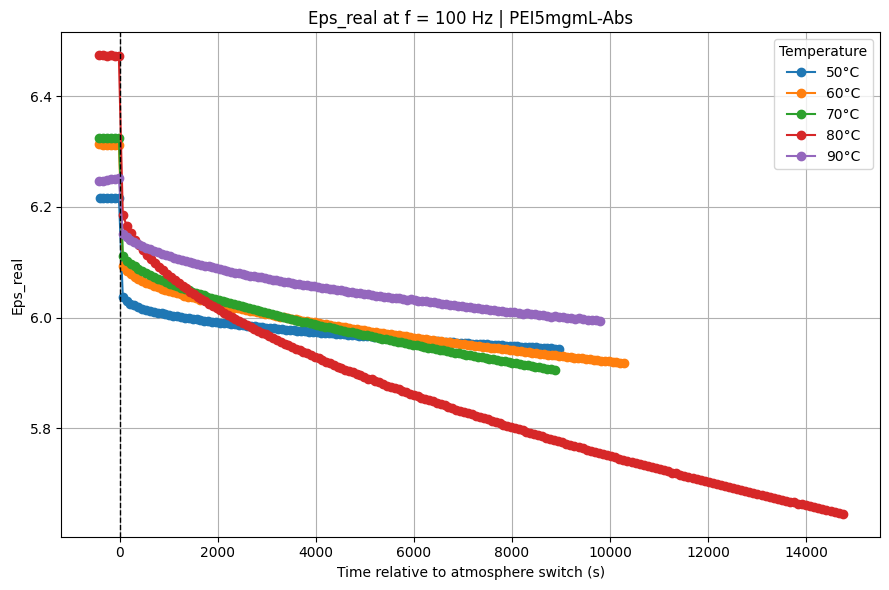

In [97]:
plot_temperature_time_series(
    df_all,
    material="PEI5mgmL",
    mode="Abs",
    target_frequency=100,
    value_col="Eps_real",
)

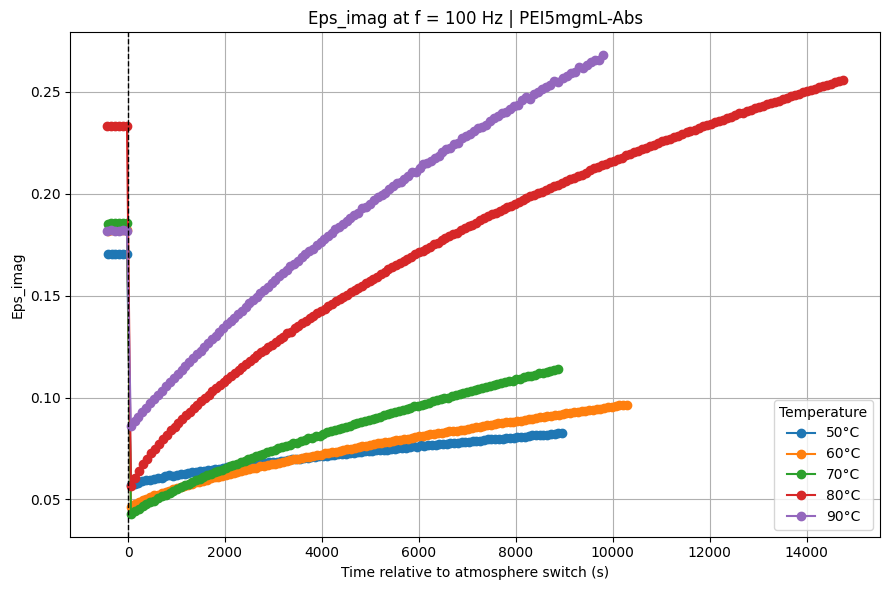

In [98]:
plot_temperature_time_series(
    df_all,
    material="PEI5mgmL",
    mode="Abs",
    target_frequency=100,
    value_col="Eps_imag",
)

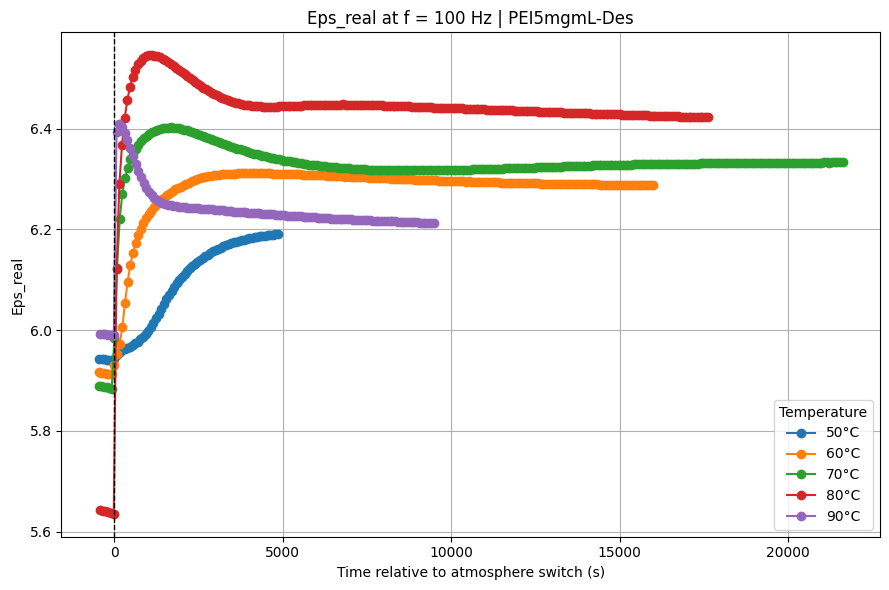

In [99]:
plot_temperature_time_series(
    df_all,
    material="PEI5mgmL",
    mode="Des",
    target_frequency=100,
    value_col="Eps_real",
)

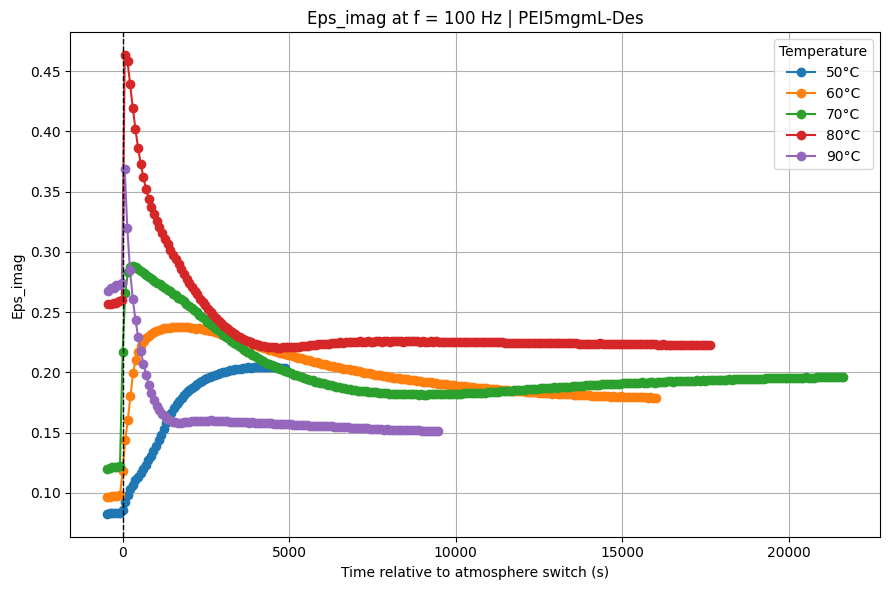

In [100]:
plot_temperature_time_series(
    df_all,
    material="PEI5mgmL",
    mode="Des",
    target_frequency=100,
    value_col="Eps_imag",
)

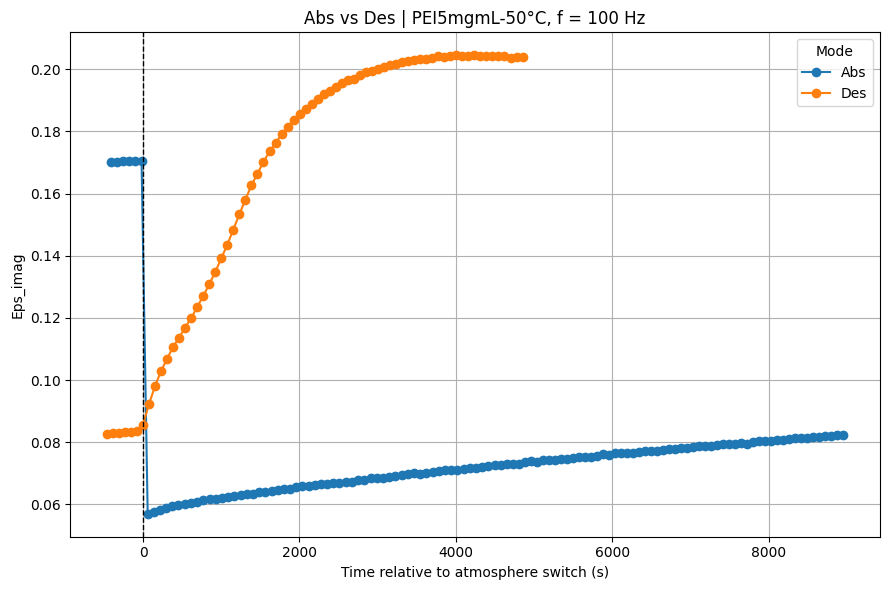

In [101]:
plot_mode_comparison(
    df_all,
    material="PEI5mgmL",
    temperature="50°C",
    target_frequency=100,
    value_col="Eps_imag",
)